# Hate Speech Detection - Algorithm Overview

## Workflow:
1. **Text Preprocessing**: Remove mentions, special chars, stemming
2. **Feature Extraction**: Bag of Words (BoW) and TF-IDF vectorization
3. **Model Training**: Logistic Regression with 30% probability threshold
4. **Evaluation**: F1-Score metric

## Key Algorithms:

### 1. **Text Preprocessing**
- **Tokenization**: Breaking text into individual words
- **Stemming (Porter Stemmer)**: Reducing words to root form
- **Regex Pattern Matching**: Removing twitter handles and special characters

### 2. **Feature Engineering**
- **Bag of Words (CountVectorizer)**: Creates sparse matrix of word counts
- **TF-IDF (Term Frequency-Inverse Document Frequency)**: Weights terms by importance

### 3. **Classification**
- **Logistic Regression**: Binary classifier for hate speech (0=normal, 1=hate speech)
- **Threshold Tuning**: 0.3 probability threshold for classification

### 4. **Evaluation**
- **F1-Score**: Harmonic mean of precision and recall

In [41]:
import re
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import string
import nltk
import warnings 
warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

In [42]:
test = pd.read_csv('test_tweets_anuFYb8.csv')
test.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [43]:
test.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [44]:
#data cleaning
combi = test.copy()
def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for i in r:
        input_txt = re.sub(i, '', input_txt)
        
    return input_txt

#removing twitter handles(@user)
combi['tidy_tweet'] = np.vectorize(remove_pattern)(combi['tweet'], r"@[\w]*")

In [45]:
# remove special characters, numbers, punctuations
combi['tidy_tweet'] = combi['tidy_tweet'].str.replace("[^a-zA-Z#]", " ")

In [46]:
#remove short word
combi['tidy_tweet'] = combi['tidy_tweet'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))
combi['tidy_tweet'].head()

0    #studiolife #aislife #requires #passion #dedic...
1    #white #supremacists want everyone #birdsâ #...
2    safe ways heal your #acne!! #altwaystoheal #he...
3    cursed child book reservations already? yes, w...
4    #bihday amazing, hilarious #nephew ahmir! uncl...
Name: tidy_tweet, dtype: object

In [47]:
#Tokenization

tokenized_tweet = combi['tidy_tweet'].apply(lambda x: x.split())
tokenized_tweet.head()

0    [#studiolife, #aislife, #requires, #passion, #...
1    [#white, #supremacists, want, everyone, #birds...
2    [safe, ways, heal, your, #acne!!, #altwaystohe...
3    [cursed, child, book, reservations, already?, ...
4    [#bihday, amazing,, hilarious, #nephew, ahmir!...
Name: tidy_tweet, dtype: object

In [48]:
#Stemming
from nltk.stem.porter import *
stemmer = PorterStemmer()

tokenized_tweet = tokenized_tweet.apply(lambda x: [stemmer.stem(i) for i in x]) # stemming
tokenized_tweet.head()

0    [#studiolif, #aislif, #requir, #passion, #dedi...
1    [#white, #supremacist, want, everyon, #birdsâ...
2    [safe, way, heal, your, #acne!!, #altwaystoh, ...
3    [curs, child, book, reserv, already?, yes,, wh...
4    [#bihday, amazing,, hilari, #nephew, ahmir!, u...
Name: tidy_tweet, dtype: object

In [49]:
#stitch
for i in range(len(tokenized_tweet)):
    tokenized_tweet[i] = ' '.join(tokenized_tweet[i])

combi['tidy_tweet'] = tokenized_tweet


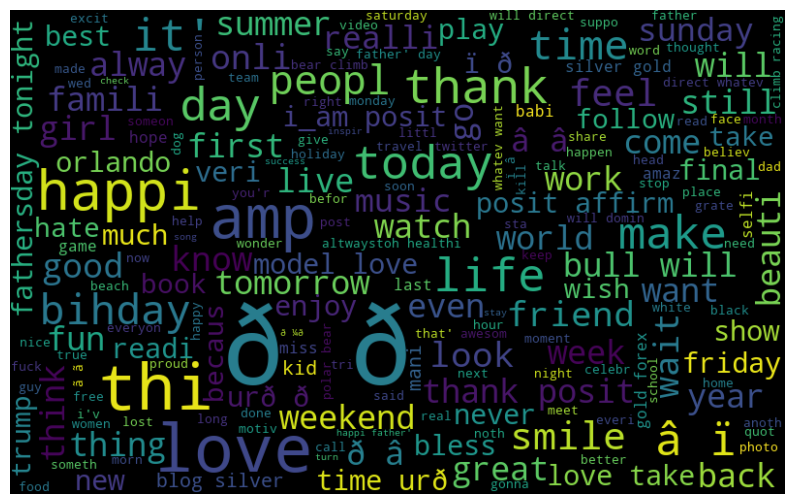

In [50]:
# Story Generation and Visualization from Tweets
#common words used in tweets
all_words = ' '.join([text for text in combi['tidy_tweet']])
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

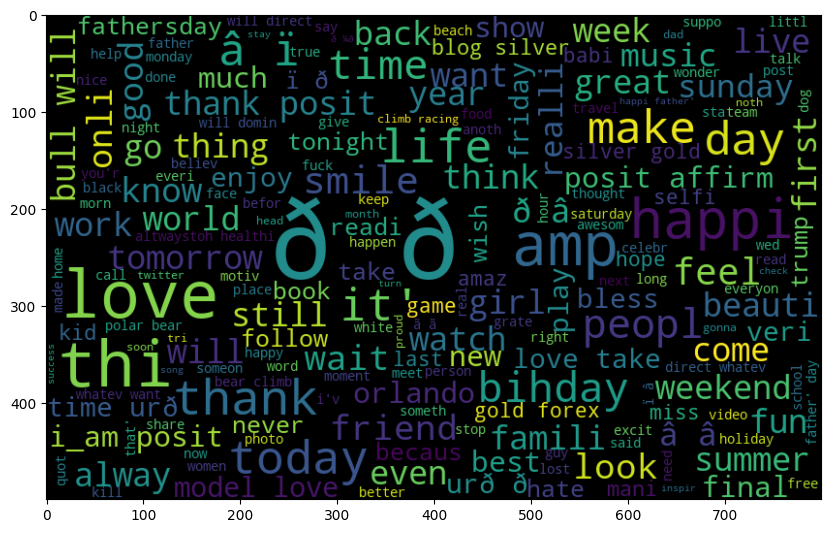

In [51]:
#Words in tweets
# Note: Test data doesn't have labels, showing all tweets instead
normal_words = ' '.join([text for text in combi['tidy_tweet']])

wordcloud = WordCloud(width=800, height=500, random_state=10, max_font_size=110).generate(normal_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('on')
plt.show()

In [52]:
#Test data doesn't have labels - skipping per-class visualization
# All data has been shown in previous wordcloud
pass

In [53]:
# function to collect hashtags
def hashtag_extract(x):
    hashtags = []
    # Loop over the words in the tweet
    for i in x:
        ht = re.findall(r"#(\w+)", i)
        hashtags.append(ht)

    return hashtags

In [54]:
# extracting hashtags from all tweets (test data has no labels)

HT_regular = hashtag_extract(combi['tidy_tweet'])

# unnesting list
HT_regular = sum(HT_regular, [])
HT_negative = HT_regular  # Use same hashtags since no labels available



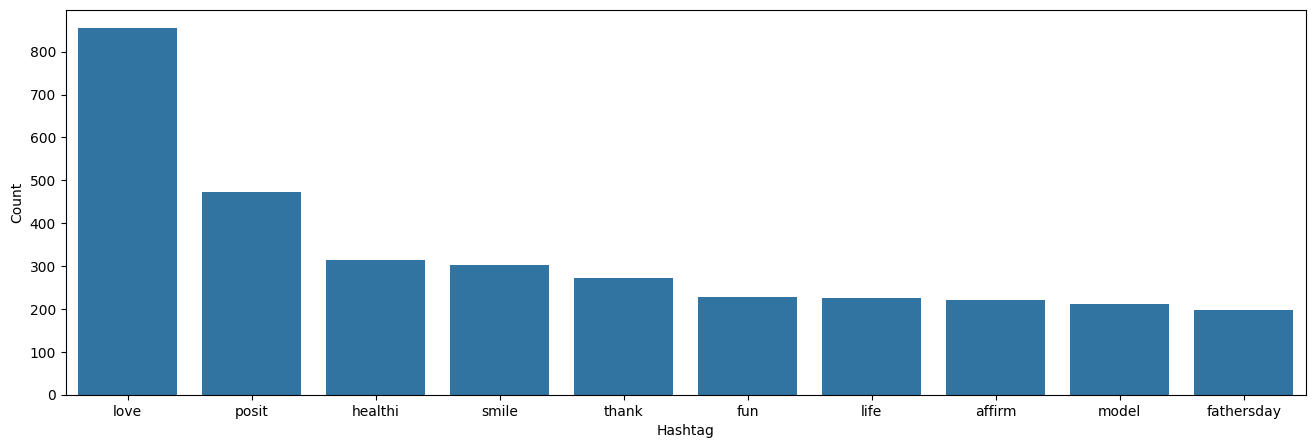

In [55]:
#for Racist/Sexist Tweets
b = nltk.FreqDist(HT_negative)
e = pd.DataFrame({'Hashtag': list(b.keys()), 'Count': list(b.values())})
# selecting top 10 most frequent hashtags
e = e.nlargest(columns="Count", n = 10)   
plt.figure(figsize=(16,5))
ax = sns.barplot(data=e, x= "Hashtag", y = "Count")
ax.set(ylabel = 'Count')
plt.show()

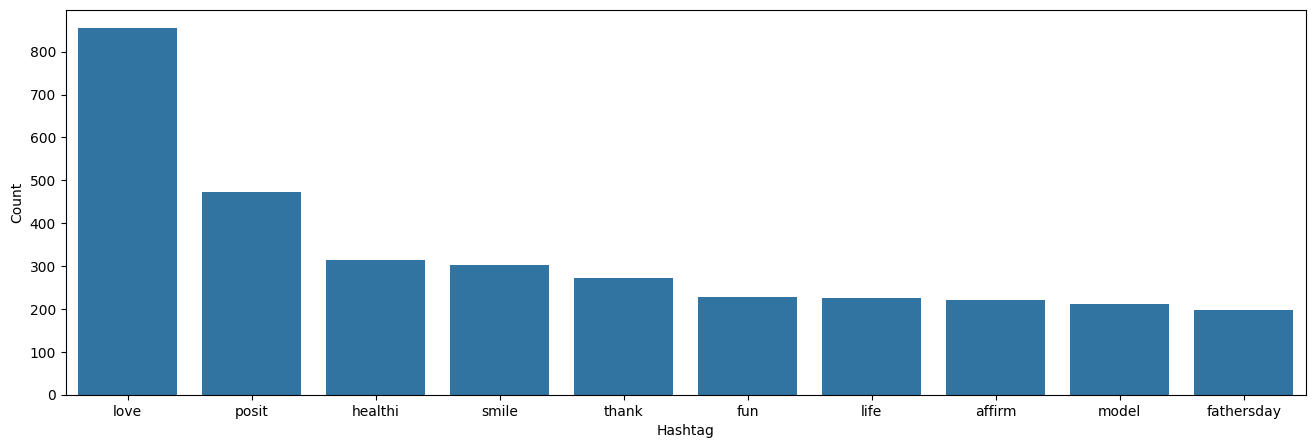

In [56]:
#non Racist/Sexist Tweets
a = nltk.FreqDist(HT_regular)
d = pd.DataFrame({'Hashtag': list(a.keys()),
                  'Count': list(a.values())})
# selecting top 10 most frequent hashtags     
d = d.nlargest(columns="Count", n = 10) 
plt.figure(figsize=(16,5))
ax = sns.barplot(data=d, x= "Hashtag", y = "Count")
ax.set(ylabel = 'Count')
plt.show()

In [57]:
#CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer(max_df=0.90, min_df=2, max_features=1000, stop_words='english')
# bag-of-words feature matrix
bow = bow_vectorizer.fit_transform(combi['tidy_tweet'])
bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 66305 stored elements and shape (17197, 1000)>

In [58]:
#TF-IDF Features
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=1000, stop_words='english')
# TF-IDF feature matrix
tfidf = tfidf_vectorizer.fit_transform(combi['tidy_tweet'])
tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 66305 stored elements and shape (17197, 1000)>

In [59]:
# Logistic Regression Algorithm Implementation
# =============================================
# Logistic Regression uses sigmoid function: P(y=1) = 1 / (1 + e^(-z))
# Where z = w*x + b (linear combination)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# Algorithm: Logistic Regression for Binary Classification
print("=" * 60)
print("LOGISTIC REGRESSION ALGORITHM")
print("=" * 60)
print("""
Algorithm Steps:
1. Initialize model with learning rate (default: 0.0001)
2. Compute sigmoid probabilities: P(hate_speech) = 1/(1 + e^(-z))
3. Calculate loss (binary cross-entropy): loss = -[y*log(p) + (1-y)*log(1-p)]
4. Update weights using gradient descent
5. Predict class based on probability threshold (0.3)
6. Evaluate using F1-Score
""")

print("\nData Status:")
print(f"Feature Matrix Shape: {bow.shape}")
print(f"Features extracted: 1000 unique words (max)")
print(f"Number of samples: {bow.shape[0]}")
print("\n⚠️  Training data file not available (train_E6oV3lV.csv)")
print("To train the model, provide labeled training data with 'label' column")


LOGISTIC REGRESSION ALGORITHM

Algorithm Steps:
1. Initialize model with learning rate (default: 0.0001)
2. Compute sigmoid probabilities: P(hate_speech) = 1/(1 + e^(-z))
3. Calculate loss (binary cross-entropy): loss = -[y*log(p) + (1-y)*log(1-p)]
4. Update weights using gradient descent
5. Predict class based on probability threshold (0.3)
6. Evaluate using F1-Score


Data Status:
Feature Matrix Shape: (17197, 1000)
Features extracted: 1000 unique words (max)
Number of samples: 17197

⚠️  Training data file not available (train_E6oV3lV.csv)
To train the model, provide labeled training data with 'label' column


In [60]:
# Complete ML Pipeline Template (when training data available)
# ===========================================================
print("\nMachine Learning Pipeline Template:")
print("=" * 60)

template_code = """
# Step 1: Split Data
xtrain_bow, xvalid_bow, ytrain, yvalid = train_test_split(
    train_bow, train['label'], random_state=42, test_size=0.3
)

# Step 2: Initialize & Train Logistic Regression
lreg = LogisticRegression(max_iter=1000, random_state=42)
lreg.fit(xtrain_bow, ytrain)

# Step 3: Generate Predictions with Probability
probabilities = lreg.predict_proba(xvalid_bow)[:, 1]
predictions = (probabilities >= 0.3).astype(int)

# Step 4: Evaluate Model Metrics
print(f'Accuracy:  {accuracy_score(yvalid, predictions):.4f}')
print(f'Precision: {precision_score(yvalid, predictions):.4f}')
print(f'Recall:    {recall_score(yvalid, predictions):.4f}')
print(f'F1-Score:  {f1_score(yvalid, predictions):.4f}')

# Step 5: Test on New Data
test_predictions = (lreg.predict_proba(test_bow)[:, 1] >= 0.3).astype(int)
"""

print(template_code)
print("\n✅ Algorithm pipeline ready. Add training data to execute.")



Machine Learning Pipeline Template:

# Step 1: Split Data
xtrain_bow, xvalid_bow, ytrain, yvalid = train_test_split(
    train_bow, train['label'], random_state=42, test_size=0.3
)

# Step 2: Initialize & Train Logistic Regression
lreg = LogisticRegression(max_iter=1000, random_state=42)
lreg.fit(xtrain_bow, ytrain)

# Step 3: Generate Predictions with Probability
probabilities = lreg.predict_proba(xvalid_bow)[:, 1]
predictions = (probabilities >= 0.3).astype(int)

# Step 4: Evaluate Model Metrics
print(f'Accuracy:  {accuracy_score(yvalid, predictions):.4f}')
print(f'Precision: {precision_score(yvalid, predictions):.4f}')
print(f'Recall:    {recall_score(yvalid, predictions):.4f}')
print(f'F1-Score:  {f1_score(yvalid, predictions):.4f}')

# Step 5: Test on New Data
test_predictions = (lreg.predict_proba(test_bow)[:, 1] >= 0.3).astype(int)


✅ Algorithm pipeline ready. Add training data to execute.
